In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings for display
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [128]:
# Load the main files

transactions = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/transaction_data.csv")
products = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/product.csv")
campaigns = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/campaign_table.csv")
campaign_desc = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/campaign_desc.csv")
coupon = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/coupon.csv")
coupon_redempt = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/coupon_redempt.csv")
hh_demographics = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/hh_demographic.csv")
causal_data = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/Data/causal_data.csv")


In [129]:
# Number of rows and columns

print("Transactions:", transactions.shape)
print("Products:", products.shape)
print("Campaigns:", campaigns.shape)
print("Campaign Descriptions:", campaign_desc.shape)
print("Coupons:", coupon.shape)
print("Coupon Redemptions:", coupon_redempt.shape)
print("Household Demographics:", hh_demographics.shape)
print("Causal Data:", causal_data.shape)


Transactions: (2595732, 12)
Products: (92353, 7)
Campaigns: (7208, 3)
Campaign Descriptions: (30, 4)
Coupons: (124548, 3)
Coupon Redemptions: (2318, 4)
Household Demographics: (801, 8)
Causal Data: (36786524, 5)


In [38]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [40]:
products.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [132]:
causal_data.head()

,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A
3,26190,292,70,0,A
4,26190,293,70,0,A


In [44]:
campaigns.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [46]:
campaign_desc.head()

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [48]:
coupon.head()

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [50]:
coupon_redempt.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [124]:
hh_demographics.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [138]:
import sqlite3

# Create an in-memory SQLite DB
conn = sqlite3.connect(':memory:')

# Push your transactions DataFrame into the DB
transactions.to_sql('transactions', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
causal_data.to_sql('causal_data', conn, index=False, if_exists='replace')
campaigns.to_sql('campaigns', conn, index=False, if_exists='replace')
campaign_desc.to_sql('campaign_desc', conn, index=False, if_exists='replace')
coupon.to_sql('coupon', conn, index=False, if_exists='replace')
coupon_redempt.to_sql('coupon_redempt', conn, index=False, if_exists='replace')
hh_demographics.to_sql('hh_demographics', conn, index=False, if_exists='replace')


801

In [80]:
query = """
SELECT 
    day,
    COUNT(DISTINCT basket_id) AS num_transactions,
    SUM(sales_value) AS total_sales,
    SUM(quantity) AS total_quantity,
    SUM(coupon_disc) AS total_coupon_discount,
    COUNT(DISTINCT store_id) AS distinct_stores,
    COUNT(DISTINCT household_key) AS distinct_households,
    
    -- Derived metrics
    ROUND(SUM(sales_value) * 1.0 / COUNT(DISTINCT basket_id), 2) AS avg_transaction_value,
    ROUND(SUM(quantity) * 1.0 / COUNT(DISTINCT basket_id), 2) AS avg_basket_size

FROM transactions
GROUP BY day
ORDER BY day;
"""

daily_metrics = pd.read_sql_query(query, conn)


In [82]:
daily_metrics

,DAY,num_transactions,total_sales,total_quantity,total_coupon_discount,distinct_stores,distinct_households,avg_transaction_value,avg_basket_size
0,1,16,549.31,302,-9.29,15,15,34.33,18.88
1,2,13,458.91,156,-3.55,10,12,35.30,12.00
2,3,44,1560.37,678,-2.80,30,33,35.46,15.41
3,4,44,1785.64,849,-1.10,30,36,40.58,19.30
4,5,25,856.93,368,0.00,21,23,34.28,14.72
...,...,...,...,...,...,...,...,...,...
706,707,363,10632.36,409667,-37.48,106,310,29.29,1128.56
707,708,384,9949.90,445522,-75.34,104,315,25.91,1160.21
708,709,379,11245.74,355172,-67.78,108,317,29.67,937.13
709,710,406,12758.04,424690,-86.23,104,339,31.42,1046.03


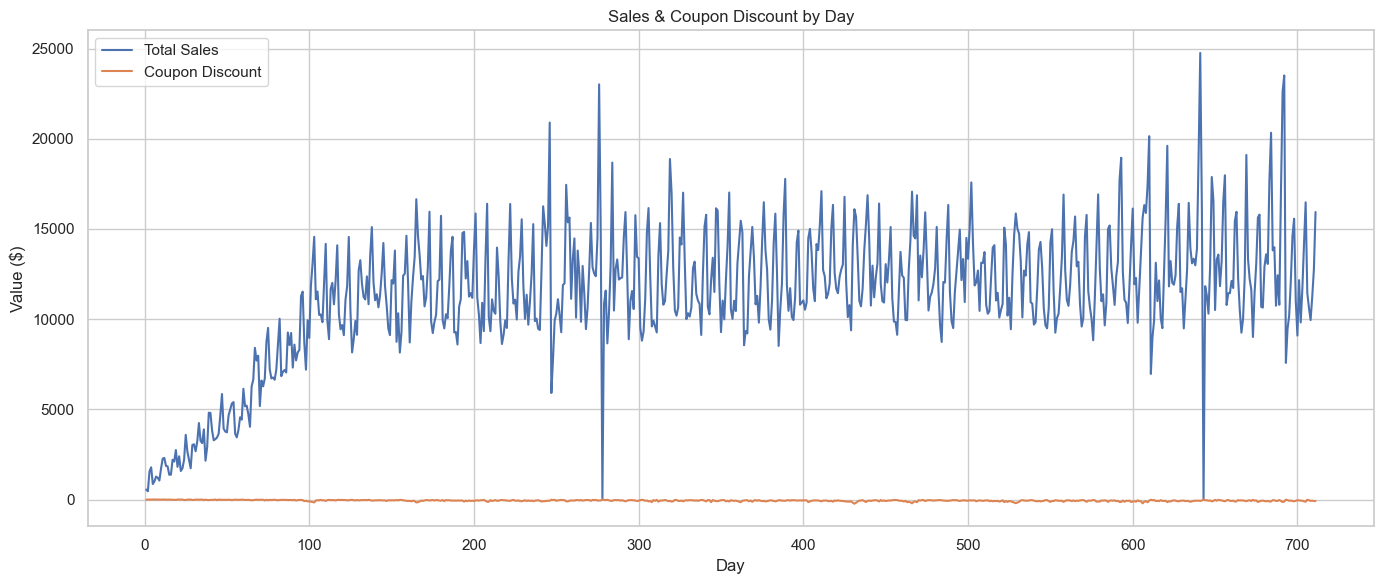

In [76]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="total_sales", label="Total Sales")
sns.lineplot(data=daily_metrics, x="DAY", y="total_coupon_discount", label="Coupon Discount")
plt.title("Sales & Coupon Discount by Day")
plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.legend()
plt.tight_layout()
plt.show()


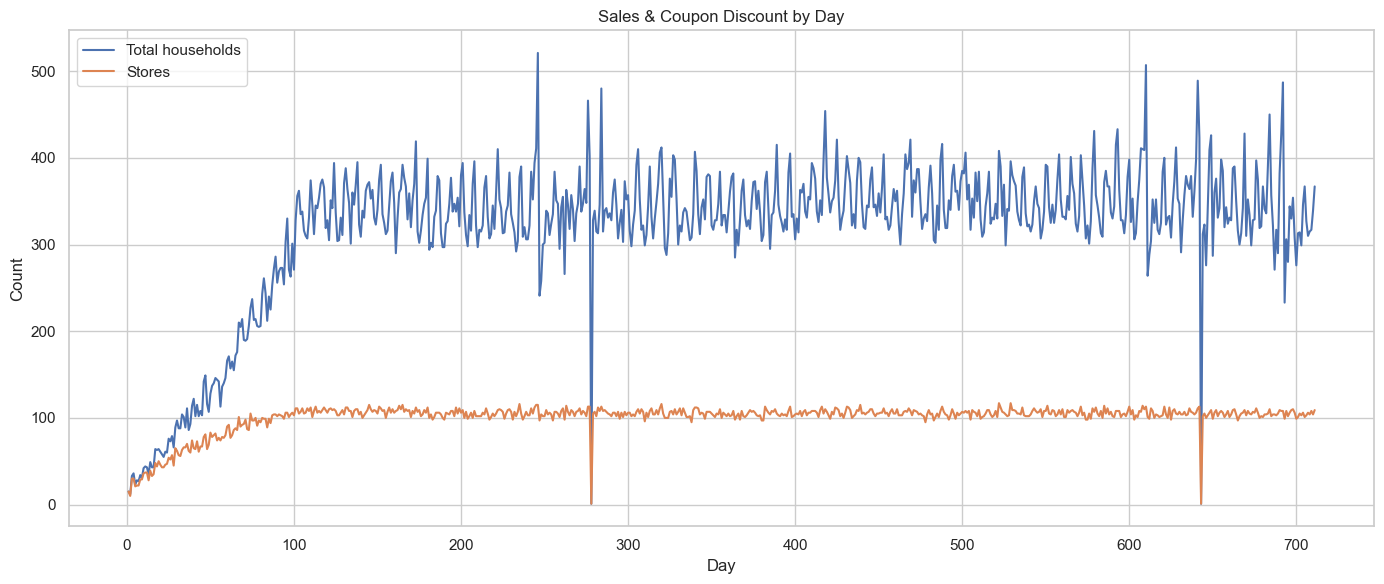

In [78]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_households", label="Total households")
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_stores", label="Stores")
plt.title("Households & Stores by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


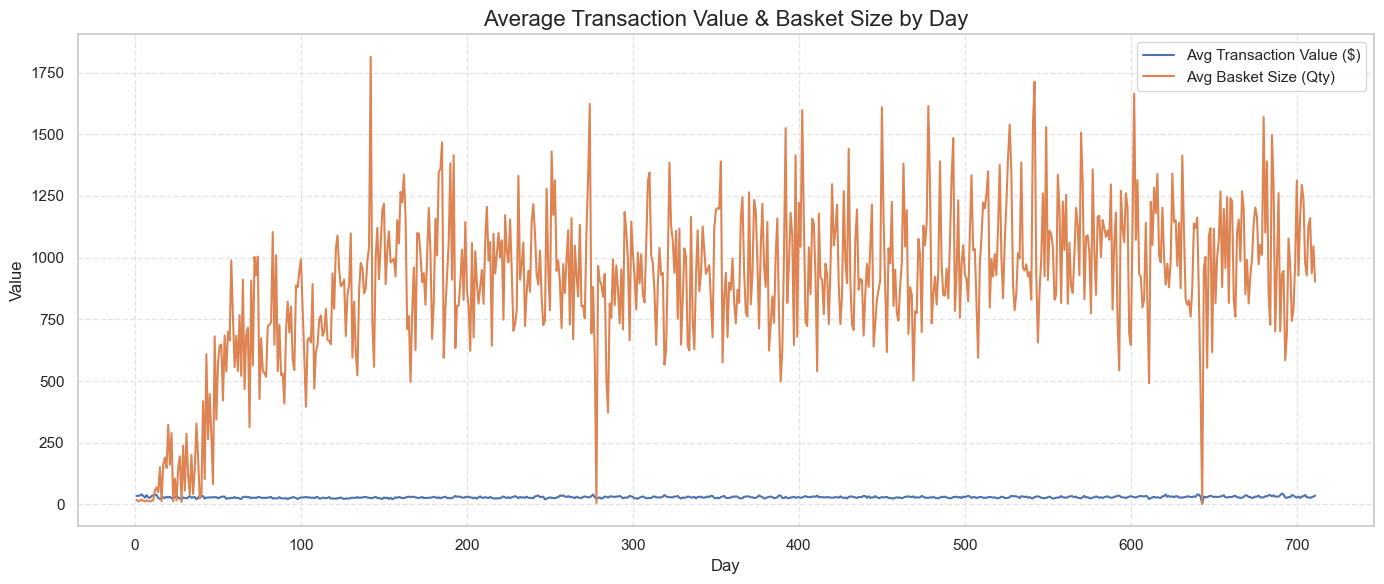

In [86]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_metrics, x="DAY", y="avg_transaction_value", label="Avg Transaction Value ($)")
sns.lineplot(data=daily_metrics, x="DAY", y="avg_basket_size", label="Avg Basket Size (Qty)")

plt.title("Average Transaction Value & Basket Size by Day", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [92]:
# Aggregate transaction table 

query1 = """
SELECT 
    COUNT(DISTINCT household_key) AS households,
    COUNT(DISTINCT BASKET_ID) AS baskets,
    COUNT(DISTINCT DAY) AS days
FROM transactions;
"""

transaction_aggregate = pd.read_sql_query(query1, conn)



,households,baskets,days
0,2500,276484,711


In [108]:
# Aggregate transaction table 

query2 = """
SELECT 
    household_key
FROM transactions
GROUP BY household_key
ORDER BY household_key;
"""

transaction_aggregate1 = pd.read_sql_query(query2, conn)



In [110]:
transaction_aggregate1

,household_key
0,1
1,2
2,3
3,4
4,5
...,...
2495,2496
2496,2497
2497,2498
2498,2499


In [139]:
# Aggregate transaction table 

query3 = """
SELECT 
    household_key
FROM hh_demographics
GROUP BY household_key
ORDER BY household_key;
"""

transaction_aggregate2 = pd.read_sql_query(query3, conn)



In [141]:
transaction_aggregate2

,household_key
0,1
1,7
2,8
3,13
4,16
...,...
796,2494
797,2496
798,2497
799,2498
